# 10. RQ2 robustness analysis


## Part A. Training-weight sensitivity


## 0. Setup

In [1]:
import json
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 2026
ALR_EPSILON = 1e-06
YEAR_REF = 8
TRAIN_END_YEAR = 7
TEST_YEAR = 8
SMALL_N_THRESHOLD = 30
SAVE_DETAILED_PREDICTIONS = False
AGE_DATA_DIR = Path('C:/Users/Lenovo/Documents/GitHub/London-Sport2-Group20/Shuhan Zhao/q3')
DISABILITY_DATA_DIR = Path('C:/Users/Lenovo/Documents/GitHub/London-Sport2-Group20/Jingyi Hua/data/processed')
OUTPUT_DIR = Path('C:/Users/Lenovo/Documents/GitHub/London-Sport2-Group20/Jingyi Hua/outputs')
SENSITIVITY_DIR = OUTPUT_DIR / 'weight_sensitivity_tuned_final'
SENSITIVITY_DIR.mkdir(parents=True, exist_ok=True)
summary = pd.read_csv(OUTPUT_DIR / 'summary_full.csv')
best_params_df = pd.read_csv(OUTPUT_DIR / 'best_hyperparameters.csv')
print('Training years: 1 to', TRAIN_END_YEAR)
print('Independent test year:', TEST_YEAR)
print('Outputs:', SENSITIVITY_DIR)


Training years: 1 to 7
Independent test year: 8
Outputs: C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\weight_sensitivity_tuned_final


## 1. Shared transformations, fixed models, and metrics

In [2]:
def shares_to_alr(shares):
    clipped = np.clip(np.asarray(shares, dtype=float), ALR_EPSILON, 1)
    clipped = clipped / clipped.sum(axis=1, keepdims=True)
    return np.log(clipped[:, :2] / clipped[:, [2]])

def alr_to_shares(values):
    values = np.clip(np.asarray(values, dtype=float), -30, 30)
    exponent = np.exp(values)
    denominator = 1 + exponent.sum(axis=1, keepdims=True)
    return np.column_stack([exponent / denominator, 1 / denominator])

def add_lag_features(frame, panel_keys, value_cols, feature_level, covid_years=(5, 6)):
    prepared = frame.sort_values(panel_keys + ['year']).reset_index(drop=True).copy()
    grouped = prepared.groupby(panel_keys, sort=False)
    for column in value_cols:
        prepared[f'{column}_lag1'] = grouped[column].shift(1)
        if feature_level == 'overall':
            prepared[f'{column}_lag2'] = grouped[column].shift(2)
        else:
            prepared[f'{column}_roll2'] = grouped[column].transform(lambda series: series.shift(1).rolling(2, min_periods=1).mean())
    prepared['time_trend'] = prepared['year'] / YEAR_REF
    prepared['is_covid_year'] = prepared['year'].isin(covid_years).astype(int)
    return prepared

def add_interaction_terms(frame, group_col, expected_cols=None):
    result = frame.copy()
    dummies = pd.get_dummies(result[group_col], prefix=f'{group_col}_x_time')
    interaction = dummies.mul(result['time_trend'], axis=0)
    if expected_cols is None:
        expected_cols = list(interaction.columns)
    interaction = interaction.reindex(columns=expected_cols, fill_value=0)
    result[expected_cols] = interaction
    return (result, expected_cols)

def select_best_model(summary_frame, task_name, metric_col):
    available = summary_frame[(summary_frame['task'] == task_name) & (summary_frame['split'] == 'validation')].copy()
    if available.empty:
        raise ValueError(f'No validation result found for {task_name}')
    return available.loc[available[metric_col].idxmin(), 'model']

PARAMETER_TASK_NAME_MAP = {
    'age_overall_level': 'age_overall',
    'disability_overall_level': 'dis_overall',
    'age_activity_level': 'age_level',
    'disability_activity_level': 'dis_level',
    'age_months12': 'age_months12',
    'disability_months12': 'months12',
    'age_days10p60gr': 'age_days',
    'disability_days10p60gr': 'days'
}

def get_best_params(task_name, model_name):
    if model_name == 'Naive baseline':
        return {}
    if task_name not in PARAMETER_TASK_NAME_MAP:
        raise KeyError(f'No parameter-task mapping has been defined for {task_name}.')
    parameter_task_name = PARAMETER_TASK_NAME_MAP[task_name]
    matching_rows = best_params_df[
        (best_params_df['task'] == parameter_task_name) &
        (best_params_df['model'] == model_name)
    ].copy()
    if matching_rows.empty:
        raise ValueError(f'No tuned parameters were found for {task_name} / {model_name}.')
    parameters = matching_rows.iloc[0].drop(['task', 'model']).dropna().to_dict()
    for parameter in ['n_estimators', 'max_depth', 'min_samples_leaf']:
        if parameter in parameters:
            parameters[parameter] = int(parameters[parameter])
    return parameters

def build_model(model_name, parameters, numeric_features, categorical_features, multi_output):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if model_name == 'Ridge Regression':
        numeric_steps.append(('scale', StandardScaler()))
    preprocess = ColumnTransformer([('numeric', Pipeline(numeric_steps), numeric_features), ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)])
    if model_name == 'Ridge Regression':
        estimator = Ridge(**parameters)
    elif model_name == 'Random Forest':
        estimator = RandomForestRegressor(**parameters, random_state=RANDOM_STATE, n_jobs=-1)
    elif model_name == 'Gradient Boosting':
        base = GradientBoostingRegressor(**parameters, random_state=RANDOM_STATE, loss='huber')
        estimator = MultiOutputRegressor(base) if multi_output else base
    else:
        raise ValueError(f'Unsupported fitted model: {model_name}')
    return Pipeline([('preprocess', preprocess), ('model', estimator)])

def safe_mean(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return float(values.mean()) if len(values) else np.nan

def safe_r2(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    valid = np.isfinite(actual) & np.isfinite(predicted)
    return r2_score(actual[valid], predicted[valid]) if valid.sum() > 1 else np.nan

def score_predictions(actual, predicted, raw_n, config):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    raw_n = np.asarray(raw_n, dtype=float)
    row = {'observations': len(actual)}
    if config['is_composition']:
        absolute = np.abs(actual - predicted)
        row_error = 0.5 * absolute.sum(axis=1)
        row['total_variation'] = safe_mean(row_error)
        row['overall_mae'] = safe_mean(absolute.ravel())
        row['overall_rmse'] = float(np.sqrt(safe_mean(((actual - predicted) ** 2).ravel())))
        for index, target in enumerate(config['target_cols']):
            row[f'{target}_mae'] = safe_mean(absolute[:, index])
            row[f'{target}_rmse'] = float(np.sqrt(safe_mean((actual[:, index] - predicted[:, index]) ** 2)))
            row[f'{target}_r2'] = safe_r2(actual[:, index], predicted[:, index])
        focus_actual = actual[:, -1]
        focus_error = absolute[:, -1]
    else:
        target = config['target_cols'][0]
        actual_vector = actual[:, 0]
        predicted_vector = predicted[:, 0]
        row_error = np.abs(actual_vector - predicted_vector)
        row[f'{target}_mae'] = safe_mean(row_error)
        row[f'{target}_rmse'] = float(np.sqrt(mean_squared_error(actual_vector, predicted_vector)))
        row[f'{target}_r2'] = safe_r2(actual_vector, predicted_vector)
        focus_actual = actual_vector
        focus_error = row_error
    positive = focus_actual > 0
    zero = focus_actual == 0
    small = np.isfinite(raw_n) & (raw_n < SMALL_N_THRESHOLD)
    large = np.isfinite(raw_n) & (raw_n >= SMALL_N_THRESHOLD)
    row['positive_cell_observations'] = int(positive.sum())
    row['positive_cell_mae'] = safe_mean(focus_error[positive])
    row['zero_cell_observations'] = int(zero.sum())
    row['zero_cell_mae'] = safe_mean(focus_error[zero])
    row['small_n_observations'] = int(small.sum())
    row['small_n_rate'] = float(small.sum() / np.isfinite(raw_n).sum()) if np.isfinite(raw_n).sum() else np.nan
    row['small_n_mean_error'] = safe_mean(row_error[small])
    row['large_n_observations'] = int(large.sum())
    row['large_n_mean_error'] = safe_mean(row_error[large])
    return row


## 2. Load the eight panels and define the fixed analysis

In [3]:
age_overall = pd.read_csv(AGE_DATA_DIR / 'q3_age_overall_activity_level_panel.csv')
age_activity = pd.read_csv(AGE_DATA_DIR / 'q3_age_activity_participation_level_panel_complete.csv')
disability_overall = pd.read_csv(DISABILITY_DATA_DIR / 'RQ3_borough_disability_overall_all_years.csv')
disability_activity = pd.read_csv(DISABILITY_DATA_DIR / 'RQ3_borough_disability_MEMS7GR_all_years.csv')
disability_rates = pd.read_csv(DISABILITY_DATA_DIR / 'RQ3_borough_disability_days_months_all_years.csv')
for frame in [age_overall, age_activity, disability_overall, disability_activity, disability_rates]:
    frame['LA_2023'] = frame['LA_2023'].astype('Int64').astype(str)
assert age_activity['activity_suffix'].nunique() == 124
assert disability_activity['activity'].nunique() == 124
assert disability_rates['activity'].nunique() == 124
TASKS = {'age_overall_level': {'task': 'age_overall_level', 'panel_keys': ['LA_2023', 'age_group'], 'target_cols': ['overall_inactive_rate', 'overall_fairly_active_rate', 'overall_active_rate'], 'weight_col': 'weighted_n_overall_activity_level', 'n_col': 'n_overall_activity_level', 'feature_level': 'overall', 'is_composition': True, 'selection_metric': 'total_variation'}, 'disability_overall_level': {'task': 'disability_overall_level', 'panel_keys': ['LA_2023', 'disability_group'], 'target_cols': ['inactive_rate', 'fairly_active_rate', 'active_rate'], 'weight_col': 'weighted_n', 'n_col': 'n', 'feature_level': 'overall', 'is_composition': True, 'selection_metric': 'total_variation'}, 'age_activity_level': {'task': 'age_activity_level', 'panel_keys': ['LA_2023', 'age_group', 'activity_suffix'], 'target_cols': ['activity_inactive_rate', 'activity_fairly_active_rate', 'activity_active_rate'], 'weight_col': 'weighted_n_activity_level', 'n_col': 'n_activity_level', 'feature_level': 'activity', 'is_composition': True, 'selection_metric': 'total_variation'}, 'disability_activity_level': {'task': 'disability_activity_level', 'panel_keys': ['LA_2023', 'disability_group', 'activity'], 'target_cols': ['inactive_rate', 'fairly_active_rate', 'active_rate'], 'weight_col': 'weighted_n', 'n_col': 'n', 'feature_level': 'activity', 'is_composition': True, 'selection_metric': 'total_variation'}, 'age_months12': {'task': 'age_months12', 'panel_keys': ['LA_2023', 'age_group', 'activity_suffix'], 'target_cols': ['months12_rate'], 'weight_col': 'weighted_n_months12', 'n_col': 'n_months12', 'feature_level': 'activity', 'is_composition': False, 'selection_metric': 'months12_rate_mae'}, 'disability_months12': {'task': 'disability_months12', 'panel_keys': ['LA_2023', 'disability_group', 'activity'], 'target_cols': ['participation_MONTHS_12'], 'weight_col': 'weighted_n_MONTHS_12', 'n_col': 'n_MONTHS_12', 'feature_level': 'activity', 'is_composition': False, 'selection_metric': 'participation_MONTHS_12_mae'}, 'age_days10p60gr': {'task': 'age_days10p60gr', 'panel_keys': ['LA_2023', 'age_group', 'activity_suffix'], 'target_cols': ['days10p60gr_rate'], 'weight_col': 'weighted_n_days10p60gr', 'n_col': 'n_days10p60gr', 'feature_level': 'activity', 'is_composition': False, 'selection_metric': 'days10p60gr_rate_mae'}, 'disability_days10p60gr': {'task': 'disability_days10p60gr', 'panel_keys': ['LA_2023', 'disability_group', 'activity'], 'target_cols': ['participation_DAYS10P60GR'], 'weight_col': 'weighted_n_DAYS10P60GR', 'n_col': 'n_DAYS10P60GR', 'feature_level': 'activity', 'is_composition': False, 'selection_metric': 'participation_DAYS10P60GR_mae'}}
TASK_FRAMES = {'age_overall_level': age_overall, 'disability_overall_level': disability_overall, 'age_activity_level': age_activity, 'disability_activity_level': disability_activity, 'age_months12': age_activity, 'disability_months12': disability_rates, 'age_days10p60gr': age_activity, 'disability_days10p60gr': disability_rates}
selected_models = []
for task_name, config in TASKS.items():
    model_name = select_best_model(summary, task_name, config['selection_metric'])
    selected_models.append({'task': task_name, 'fixed_model': model_name, 'fixed_parameters': json.dumps(get_best_params(task_name, model_name), sort_keys=True) if model_name != 'Naive baseline' else '{}'})
selected_models = pd.DataFrame(selected_models)
display(selected_models)


,task,fixed_model,fixed_parameters
0,age_overall_level,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s..."
1,disability_overall_level,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s..."
2,age_activity_level,Random Forest,"{""max_depth"": 10, ""max_features"": 0.5, ""min_sa..."
3,disability_activity_level,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s..."
4,age_months12,Naive baseline,{}
5,disability_months12,Ridge Regression,"{""alpha"": 100.0}"
6,age_days10p60gr,Naive baseline,{}
7,disability_days10p60gr,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s..."


## 3. Fit each fixed model under the two weighting schemes

In [4]:
def prepare_task(frame, config):
    prepared = add_lag_features(frame, config['panel_keys'], config['target_cols'], config['feature_level'])
    prepared, interaction_cols = add_interaction_terms(prepared, config['panel_keys'][1])
    lag1_cols = [f'{column}_lag1' for column in config['target_cols']]
    extra_cols = [f'{column}_lag2' if config['feature_level'] == 'overall' else f'{column}_roll2' for column in config['target_cols']]
    numeric = lag1_cols + extra_cols + ['time_trend', 'is_covid_year']
    return (prepared, lag1_cols, numeric, interaction_cols)

def fit_and_evaluate_weight_scheme(prepared, config, model_name, parameters, scheme_name, lag1_cols, numeric, interaction_cols):
    targets = config['target_cols']
    history_feature_cols = [column for column in numeric if column not in ['time_trend', 'is_covid_year']]
    required_train = targets + [config['weight_col'], config['n_col']]
    train = prepared[prepared['year'] <= TRAIN_END_YEAR].dropna(subset=required_train).copy()
    train = train[(pd.to_numeric(train[config['weight_col']], errors='coerce') > 0) & (pd.to_numeric(train[config['n_col']], errors='coerce') > 0)].copy()
    test = prepared[prepared['year'] == TEST_YEAR].dropna(subset=targets + history_feature_cols + [config['n_col']]).copy()
    original_weights = pd.to_numeric(train[config['weight_col']], errors='coerce').to_numpy(dtype=float)
    square_root_weights = np.sqrt(pd.to_numeric(train[config['n_col']], errors='coerce').to_numpy(dtype=float))
    square_root_weights = square_root_weights * original_weights.mean() / square_root_weights.mean()
    if scheme_name == 'weighted_n':
        training_weights = original_weights
    elif scheme_name == 'sqrt_raw_n_rescaled':
        training_weights = square_root_weights
    else:
        raise ValueError(f'Unknown weighting scheme: {scheme_name}')
    actual = test[targets].to_numpy(dtype=float)
    if model_name == 'Naive baseline':
        predicted = test[lag1_cols].to_numpy(dtype=float)
        numeric_for_model = numeric
    else:
        numeric_for_model = numeric + interaction_cols if model_name == 'Ridge Regression' else numeric
        model = build_model(model_name, parameters, numeric_for_model, config['panel_keys'], config['is_composition'])
        response = shares_to_alr(train[targets]) if config['is_composition'] else train[targets[0]].to_numpy(dtype=float)
        model.fit(train[numeric_for_model + config['panel_keys']], response, model__sample_weight=training_weights)
        raw_prediction = model.predict(test[numeric_for_model + config['panel_keys']])
        if config['is_composition']:
            predicted = alr_to_shares(raw_prediction)
        else:
            predicted = np.clip(raw_prediction, 0, 1).reshape(-1, 1)
    metrics = score_predictions(actual, predicted, test[config['n_col']].to_numpy(dtype=float), config)
    metrics.update({'task': config['task'], 'fixed_model': model_name, 'fixed_parameters': json.dumps(parameters, sort_keys=True), 'weighting_scheme': scheme_name, 'training_rows': len(train), 'original_weight_mean': original_weights.mean(), 'analysis_weight_mean': training_weights.mean(), 'analysis_weight_min': training_weights.min(), 'analysis_weight_max': training_weights.max()})
    prediction_frame = test[config['panel_keys'] + ['year', config['n_col']]].copy()
    for index, target in enumerate(targets):
        prediction_frame[f'actual_{target}'] = actual[:, index]
        prediction_frame[f'predicted_{target}'] = predicted[:, index]
    prediction_frame['task'] = config['task']
    prediction_frame['fixed_model'] = model_name
    prediction_frame['weighting_scheme'] = scheme_name
    return (metrics, prediction_frame)

def run_weight_sensitivity_task(frame, config):
    started = time.time()
    prepared, lag1_cols, numeric, interaction_cols = prepare_task(frame, config)
    model_name = select_best_model(summary, config['task'], config['selection_metric'])
    parameters = get_best_params(config['task'], model_name) if model_name != 'Naive baseline' else {}
    metric_rows = []
    prediction_frames = []
    for scheme_name in ['weighted_n', 'sqrt_raw_n_rescaled']:
        print(config['task'], scheme_name, model_name)
        metrics, predictions = fit_and_evaluate_weight_scheme(prepared, config, model_name, parameters, scheme_name, lag1_cols, numeric, interaction_cols)
        metric_rows.append(metrics)
        prediction_frames.append(predictions)
    task_metrics = pd.DataFrame(metric_rows)
    task_predictions = pd.concat(prediction_frames, ignore_index=True)
    task_metrics.to_csv(SENSITIVITY_DIR / f"{config['task']}_weight_sensitivity_metrics.csv", index=False)
    if config['feature_level'] == 'overall' or SAVE_DETAILED_PREDICTIONS:
        task_predictions.to_csv(SENSITIVITY_DIR / f"{config['task']}_weight_sensitivity_predictions.csv.gz", index=False, compression='gzip')
    print(f"Completed {config['task']} in {(time.time() - started) / 60:.1f} minutes")
    display(task_metrics.round(4))
    return (task_metrics, task_predictions)


## 4. Run all eight tasks

In [5]:
weight_sensitivity_results = {}
for task_name in TASKS:
    weight_sensitivity_results[task_name] = run_weight_sensitivity_task(TASK_FRAMES[task_name], TASKS[task_name])


age_overall_level weighted_n Gradient Boosting
age_overall_level sqrt_raw_n_rescaled Gradient Boosting
Completed age_overall_level in 0.0 minutes


,observations,total_variation,overall_mae,overall_rmse,overall_inactive_rate_mae,overall_inactive_rate_rmse,overall_inactive_rate_r2,overall_fairly_active_rate_mae,overall_fairly_active_rate_rmse,overall_fairly_active_rate_r2,...,large_n_mean_error,task,fixed_model,fixed_parameters,weighting_scheme,training_rows,original_weight_mean,analysis_weight_mean,analysis_weight_min,analysis_weight_max
0,256,0.1083,0.0722,0.1094,0.0853,0.1261,0.4289,0.0424,0.0589,-0.0084,...,0.0794,age_overall_level,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",weighted_n,1792,110.8542,110.8542,0.6859,481.3942
1,256,0.1079,0.0719,0.1112,0.0846,0.1288,0.4044,0.0430,0.0595,-0.0269,...,0.0792,age_overall_level,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",sqrt_raw_n_rescaled,1792,110.8542,110.8542,14.5643,231.2008


disability_overall_level weighted_n Gradient Boosting
disability_overall_level sqrt_raw_n_rescaled Gradient Boosting
Completed disability_overall_level in 0.1 minutes


,observations,total_variation,overall_mae,overall_rmse,inactive_rate_mae,inactive_rate_rmse,inactive_rate_r2,fairly_active_rate_mae,fairly_active_rate_rmse,fairly_active_rate_r2,...,large_n_mean_error,task,fixed_model,fixed_parameters,weighting_scheme,training_rows,original_weight_mean,analysis_weight_mean,analysis_weight_min,analysis_weight_max
0,504,0.1841,0.1227,0.1760,0.1413,0.1928,0.1111,0.0766,0.1164,-0.1066,...,0.0894,disability_overall_level,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",weighted_n,3537,73.1314,73.1314,0.1558,885.9975
1,504,0.1815,0.1210,0.1752,0.1373,0.1853,0.1787,0.0768,0.1304,-0.3885,...,0.0892,disability_overall_level,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",sqrt_raw_n_rescaled,3537,73.1314,73.1314,14.0792,371.7025


age_activity_level weighted_n Random Forest
age_activity_level sqrt_raw_n_rescaled Random Forest
Completed age_activity_level in 1.2 minutes


...

,observations,participation_MONTHS_12_mae,participation_MONTHS_12_rmse,participation_MONTHS_12_r2,positive_cell_observations,positive_cell_mae,zero_cell_observations,zero_cell_mae,small_n_observations,small_n_rate,...,large_n_mean_error,task,fixed_model,fixed_parameters,weighting_scheme,training_rows,original_weight_mean,analysis_weight_mean,analysis_weight_min,analysis_weight_max
0,62392,0.0212,0.0609,0.6260,12138,0.0681,50254,0.0099,42560,0.6821,...,0.0158,disability_months12,Ridge Regression,"{""alpha"": 100.0}",weighted_n,434104,65.8183,65.8183,0.1558,885.9975
1,62392,0.0200,0.0588,0.6524,12138,0.0669,50254,0.0086,42560,0.6821,...,0.0156,disability_months12,Ridge Regression,"{""alpha"": 100.0}",sqrt_raw_n_rescaled,434104,65.8183,65.8183,13.6076,359.2508


age_days10p60gr weighted_n Naive baseline
age_days10p60gr sqrt_raw_n_rescaled Naive baseline
Completed age_days10p60gr in 0.1 minutes


,observations,days10p60gr_rate_mae,days10p60gr_rate_rmse,days10p60gr_rate_r2,positive_cell_observations,positive_cell_mae,zero_cell_observations,zero_cell_mae,small_n_observations,small_n_rate,...,large_n_mean_error,task,fixed_model,fixed_parameters,weighting_scheme,training_rows,original_weight_mean,analysis_weight_mean,analysis_weight_min,analysis_weight_max
0,31585,0.0091,0.0328,0.764,5716,0.0412,25869,0.002,7702,0.2438,...,0.0088,age_days10p60gr,Naive baseline,{},weighted_n,220889,101.6366,101.6366,0.3923,481.3942
1,31585,0.0091,0.0328,0.764,5716,0.0412,25869,0.002,7702,0.2438,...,0.0088,age_days10p60gr,Naive baseline,{},sqrt_raw_n_rescaled,220889,101.6366,101.6366,14.1236,224.2056


disability_days10p60gr weighted_n Gradient Boosting
disability_days10p60gr sqrt_raw_n_rescaled Gradient Boosting
Completed disability_days10p60gr in 1.2 minutes


,observations,participation_DAYS10P60GR_mae,participation_DAYS10P60GR_rmse,participation_DAYS10P60GR_r2,positive_cell_observations,positive_cell_mae,zero_cell_observations,zero_cell_mae,small_n_observations,small_n_rate,...,large_n_mean_error,task,fixed_model,fixed_parameters,weighting_scheme,training_rows,original_weight_mean,analysis_weight_mean,analysis_weight_min,analysis_weight_max
0,62392,0.0092,0.0419,0.5475,6309,0.0637,56083,0.0030,42560,0.6821,...,0.0069,disability_days10p60gr,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",weighted_n,434100,65.7821,65.7821,0.1558,885.9975
1,62392,0.0085,0.0408,0.5705,6309,0.0647,56083,0.0022,42560,0.6821,...,0.0069,disability_days10p60gr,Gradient Boosting,"{""learning_rate"": 0.05, ""max_depth"": 2, ""min_s...",sqrt_raw_n_rescaled,434100,65.7821,65.7821,13.6000,359.0514


## 5. Combine, compare, and save the reporting tables

In [6]:
all_weight_metrics = pd.concat([result[0] for result in weight_sensitivity_results.values()], ignore_index=True)
comparison_rows = []
for task_name, config in TASKS.items():
    task_metrics = all_weight_metrics[all_weight_metrics['task'] == task_name].copy()
    original = task_metrics[task_metrics['weighting_scheme'] == 'weighted_n'].iloc[0]
    sensitivity = task_metrics[task_metrics['weighting_scheme'] == 'sqrt_raw_n_rescaled'].iloc[0]
    primary_metric = 'total_variation' if config['is_composition'] else f"{config['target_cols'][0]}_mae"
    original_value = float(original[primary_metric])
    sensitivity_value = float(sensitivity[primary_metric])
    absolute_change = sensitivity_value - original_value
    percentage_change = 100 * absolute_change / original_value if np.isfinite(original_value) and original_value > 0 else np.nan
    comparison_rows.append({'task': task_name, 'fixed_model': original['fixed_model'], 'primary_metric': primary_metric, 'weighted_n_value': original_value, 'sqrt_raw_n_rescaled_value': sensitivity_value, 'absolute_change': absolute_change, 'percentage_change': percentage_change, 'weighted_n_positive_cell_mae': original['positive_cell_mae'], 'sqrt_raw_n_rescaled_positive_cell_mae': sensitivity['positive_cell_mae'], 'positive_cell_mae_change': sensitivity['positive_cell_mae'] - original['positive_cell_mae'], 'same_prediction_expected': original['fixed_model'] == 'Naive baseline'})
weight_sensitivity_comparison = pd.DataFrame(comparison_rows)
all_weight_metrics.to_csv(SENSITIVITY_DIR / 'all_tasks_weight_sensitivity_metrics.csv', index=False)
weight_sensitivity_comparison.to_csv(SENSITIVITY_DIR / 'weight_sensitivity_reporting_table.csv', index=False)
selected_models.to_csv(SENSITIVITY_DIR / 'weight_sensitivity_fixed_models.csv', index=False)
assert len(all_weight_metrics) == len(TASKS) * 2
assert len(weight_sensitivity_comparison) == len(TASKS)
assert np.isfinite(weight_sensitivity_comparison['weighted_n_value']).all()
assert np.isfinite(weight_sensitivity_comparison['sqrt_raw_n_rescaled_value']).all()
print('Weight-sensitivity analysis completed and saved to:', SENSITIVITY_DIR)
display(weight_sensitivity_comparison.round(4))


Weight-sensitivity analysis completed and saved to: C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\weight_sensitivity_tuned_final


,task,fixed_model,primary_metric,weighted_n_value,sqrt_raw_n_rescaled_value,absolute_change,percentage_change,weighted_n_positive_cell_mae,sqrt_raw_n_rescaled_positive_cell_mae,positive_cell_mae_change,same_prediction_expected
0,age_overall_level,Gradient Boosting,total_variation,0.1083,0.1079,-0.0004,-0.3708,0.0857,0.0856,-0.0001,False
1,disability_overall_level,Gradient Boosting,total_variation,0.1841,0.1815,-0.0026,-1.4122,0.1342,0.1334,-0.0008,False
2,age_activity_level,Random Forest,total_variation,0.0080,0.0081,0.0001,1.1894,0.0375,0.0379,0.0004,False
3,disability_activity_level,Gradient Boosting,total_variation,0.0081,0.0079,-0.0002,-2.1596,0.0693,0.0659,-0.0034,False
4,age_months12,Naive baseline,months12_rate_mae,0.0170,0.0170,0.0000,0.0000,0.0420,0.0420,0.0000,True
5,disability_months12,Ridge Regression,participation_MONTHS_12_mae,0.0212,0.0200,-0.0012,-5.8794,0.0681,0.0669,-0.0012,False
6,age_days10p60gr,Naive baseline,days10p60gr_rate_mae,0.0091,0.0091,0.0000,0.0000,0.0412,0.0412,0.0000,True
7,disability_days10p60gr,Gradient Boosting,participation_DAYS10P60GR_mae,0.0092,0.0085,-0.0007,-7.1101,0.0637,0.0647,0.0010,False


# Part B. Overall residual recursive simulation



## 0. Setup

In [7]:
import json
import time
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 2026
ALR_EPSILON = 1e-06
YEAR_REF = 8
FORECAST_START_YEAR = 8
FORECAST_HORIZON = 8
N_SIMULATIONS = 500
SIMULATION_BATCH_SIZE = 50
LOWER_QUANTILE = 0.05
UPPER_QUANTILE = 0.95
AGE_DATA_DIR = Path('C:/Users/Lenovo/Documents/GitHub/London-Sport2-Group20/Shuhan Zhao/q3')
DISABILITY_DATA_DIR = Path('C:/Users/Lenovo/Documents/GitHub/London-Sport2-Group20/Jingyi Hua/data/processed')
OUTPUT_DIR = Path('C:/Users/Lenovo/Documents/GitHub/London-Sport2-Group20/Jingyi Hua/outputs')
SIMULATION_DIR = OUTPUT_DIR / 'overall_residual_simulation'
SIMULATION_DIR.mkdir(parents=True, exist_ok=True)
summary = pd.read_csv(OUTPUT_DIR / 'summary_full.csv')
best_params_df = pd.read_csv(OUTPUT_DIR / 'best_hyperparameters.csv')
print('Simulations per task:', N_SIMULATIONS)
print('Forecast years: 9 to', FORECAST_START_YEAR + FORECAST_HORIZON)
print('Outputs:', SIMULATION_DIR)


Simulations per task: 500
Forecast years: 9 to 16
Outputs: C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\overall_residual_simulation


## 1. Shared transformations and fixed model construction

In [8]:
def shares_to_alr(shares):
    clipped = np.clip(np.asarray(shares, dtype=float), ALR_EPSILON, 1)
    clipped = clipped / clipped.sum(axis=1, keepdims=True)
    return np.log(clipped[:, :2] / clipped[:, [2]])

def alr_to_shares(values):
    values = np.clip(np.asarray(values, dtype=float), -30, 30)
    exponent = np.exp(values)
    denominator = 1 + exponent.sum(axis=1, keepdims=True)
    return np.column_stack([exponent / denominator, 1 / denominator])

def add_lag_features(frame, panel_keys, value_cols, feature_level='overall', covid_years=(5, 6)):
    prepared = frame.sort_values(panel_keys + ['year']).reset_index(drop=True).copy()
    grouped = prepared.groupby(panel_keys, sort=False)
    for column in value_cols:
        prepared[f'{column}_lag1'] = grouped[column].shift(1)

        if feature_level == 'overall':
            prepared[f'{column}_lag2'] = grouped[column].shift(2)
        else:
            prepared[f'{column}_roll2'] = grouped[column].transform(
                lambda series: series.shift(1).rolling(2, min_periods=1).mean()
            )

    prepared['time_trend'] = prepared['year'] / YEAR_REF
    prepared['is_covid_year'] = prepared['year'].isin(covid_years).astype(int)
    return prepared

def add_interaction_terms(frame, group_col, expected_cols=None):
    result = frame.copy()
    dummies = pd.get_dummies(result[group_col], prefix=f'{group_col}_x_time')
    interaction = dummies.mul(result['time_trend'], axis=0)
    if expected_cols is None:
        expected_cols = list(interaction.columns)
    interaction = interaction.reindex(columns=expected_cols, fill_value=0)
    result[expected_cols] = interaction
    return (result, expected_cols)

def select_best_model(summary_frame, task_name, metric_col='total_variation'):
    available = summary_frame[(summary_frame['task'] == task_name) & (summary_frame['split'] == 'validation')].copy()
    if available.empty:
        raise ValueError(f'No validation result found for {task_name}')
    return available.loc[available[metric_col].idxmin(), 'model']

PARAMETER_TASK_NAME_MAP = {
    'age_overall_level': 'age_overall',
    'disability_overall_level': 'dis_overall',
    'age_activity_level': 'age_level',
    'disability_activity_level': 'dis_level',
    'age_months12': 'age_months12',
    'disability_months12': 'months12',
    'age_days10p60gr': 'age_days',
    'disability_days10p60gr': 'days'
}

def get_best_params(task_name, model_name):
    if model_name == 'Naive baseline':
        return {}
    if task_name not in PARAMETER_TASK_NAME_MAP:
        raise KeyError(f'No parameter-task mapping has been defined for {task_name}.')
    parameter_task_name = PARAMETER_TASK_NAME_MAP[task_name]
    matching_rows = best_params_df[
        (best_params_df['task'] == parameter_task_name) &
        (best_params_df['model'] == model_name)
    ].copy()
    if matching_rows.empty:
        raise ValueError(f'No tuned parameters were found for {task_name} / {model_name}.')
    parameters = matching_rows.iloc[0].drop(['task', 'model']).dropna().to_dict()
    for parameter in ['n_estimators', 'max_depth', 'min_samples_leaf']:
        if parameter in parameters:
            parameters[parameter] = int(parameters[parameter])
    return parameters

def build_model(model_name, parameters, numeric_features, categorical_features, multi_output=True):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if model_name == 'Ridge Regression':
        numeric_steps.append(('scale', StandardScaler()))
    preprocess = ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
    if model_name == 'Ridge Regression':
        estimator = Ridge(**parameters)
    elif model_name == 'Random Forest':
        estimator = RandomForestRegressor(
            **parameters, random_state=RANDOM_STATE, n_jobs=-1
        )
    elif model_name == 'Gradient Boosting':
        base = GradientBoostingRegressor(
            **parameters, random_state=RANDOM_STATE, loss='huber'
        )
        estimator = MultiOutputRegressor(base) if multi_output else base
    else:
        raise ValueError(f'Unsupported fitted model: {model_name}')
    return Pipeline([
        ('preprocess', preprocess),
        ('model', estimator)
    ])

## 2. Load the two overall panels

In [9]:
age_overall = pd.read_csv(AGE_DATA_DIR / 'q3_age_overall_activity_level_panel.csv')
disability_overall = pd.read_csv(DISABILITY_DATA_DIR / 'RQ3_borough_disability_overall_all_years.csv')
for frame in [age_overall, disability_overall]:
    frame['LA_2023'] = frame['LA_2023'].astype('Int64').astype(str)
OVERALL_TASKS = {'age_overall_level': {'task': 'age_overall_level', 'panel_keys': ['LA_2023', 'age_group'], 'target_cols': ['overall_inactive_rate', 'overall_fairly_active_rate', 'overall_active_rate'], 'weight_col': 'weighted_n_overall_activity_level'}, 'disability_overall_level': {'task': 'disability_overall_level', 'panel_keys': ['LA_2023', 'disability_group'], 'target_cols': ['inactive_rate', 'fairly_active_rate', 'active_rate'], 'weight_col': 'weighted_n'}}
OVERALL_FRAMES = {'age_overall_level': age_overall, 'disability_overall_level': disability_overall}
for task_name, config in OVERALL_TASKS.items():
    model_name = select_best_model(summary, task_name)
    print(task_name, 'fixed model:', model_name, 'parameters:', get_best_params(task_name, model_name))


age_overall_level fixed model: Gradient Boosting parameters: {'n_estimators': 120, 'max_depth': 2, 'min_samples_leaf': 15, 'learning_rate': 0.05}
disability_overall_level fixed model: Gradient Boosting parameters: {'n_estimators': 120, 'max_depth': 2, 'min_samples_leaf': 15, 'learning_rate': 0.05}


## 3. Build the Year 8 residual pool and run recursive simulations

In [10]:
def prepare_overall_task(frame, config):
    prepared = add_lag_features(frame, config['panel_keys'], config['target_cols'])
    prepared, interaction_cols = add_interaction_terms(prepared, config['panel_keys'][1])
    lag1_cols = [f'{column}_lag1' for column in config['target_cols']]
    lag2_cols = [f'{column}_lag2' for column in config['target_cols']]
    numeric = lag1_cols + lag2_cols + ['time_trend', 'is_covid_year']
    return (prepared, lag1_cols, lag2_cols, numeric, interaction_cols)

def fit_fixed_overall_model(prepared, config, model_name, parameters, final_training_year, numeric, interaction_cols):
    history_feature_cols = [column for column in numeric if column not in ['time_trend', 'is_covid_year']]
    train = prepared[prepared['year'] <= final_training_year].dropna(
    subset=config['target_cols'] + [config['weight_col']]
).copy()
    train = train[pd.to_numeric(train[config['weight_col']], errors='coerce') > 0].copy()
    if model_name == 'Naive baseline':
        return (None, numeric)
    numeric_for_model = numeric + interaction_cols if model_name == 'Ridge Regression' else numeric
    model = build_model(model_name, parameters, numeric_for_model, config['panel_keys'])
    model.fit(train[numeric_for_model + config['panel_keys']], shares_to_alr(train[config['target_cols']]), model__sample_weight=train[config['weight_col']].to_numpy(dtype=float))
    return (model, numeric_for_model)

def predict_alr(model, model_name, frame, config, numeric_for_model, lag1_cols):
    if model_name == 'Naive baseline':
        return shares_to_alr(frame[lag1_cols].to_numpy(dtype=float))
    return np.asarray(model.predict(frame[numeric_for_model + config['panel_keys']]), dtype=float)

def build_year8_residual_pool(prepared, config, model_name, parameters, lag1_cols, numeric, interaction_cols):
    validation_model, numeric_for_model = fit_fixed_overall_model(prepared, config, model_name, parameters, final_training_year=7, numeric=numeric, interaction_cols=interaction_cols)
    year8 = prepared[prepared['year'] == 8].dropna(subset=config['target_cols'] + [column for column in numeric if column not in ['time_trend', 'is_covid_year']]).copy()
    predicted_alr = predict_alr(validation_model, model_name, year8, config, numeric_for_model, lag1_cols)
    actual_alr = shares_to_alr(year8[config['target_cols']])
    residual_pool = actual_alr - predicted_alr
    residual_pool = residual_pool[np.isfinite(residual_pool).all(axis=1)]
    residual_pool = residual_pool - residual_pool.mean(axis=0, keepdims=True)
    if len(residual_pool) < 30:
        raise ValueError(f"Residual pool is unexpectedly small for {config['task']}: {len(residual_pool)}")
    return residual_pool

def build_forecast_seed(frame, config):
    seed = frame[frame['year'].isin([7, 8])].dropna(subset=config['target_cols']).sort_values(config['panel_keys'] + ['year'])
    history = {}
    for key, group in seed.groupby(config['panel_keys'], sort=False):
        key = key if isinstance(key, tuple) else (key,)
        if set(group['year']) != {7, 8}:
            continue
        history[key] = group[config['target_cols']].to_numpy(dtype=float).tolist()
    if not history:
        raise ValueError(f"No complete Year 7 and Year 8 seed panels for {config['task']}")
    return history

def construct_recursive_features(history, config, forecast_year):
    feature_rows = []
    active_keys = list(history.keys())
    for key in active_keys:
        values = history[key]
        last = values[-1]
        previous = values[-2]
        row = dict(zip(config['panel_keys'], key))
        for index, target in enumerate(config['target_cols']):
            row[f'{target}_lag1'] = last[index]
            row[f'{target}_lag2'] = previous[index]
        row['time_trend'] = forecast_year / YEAR_REF
        row['is_covid_year'] = 0
        feature_rows.append(row)
    return (pd.DataFrame(feature_rows), active_keys)

def simulate_overall_task(frame, config):
    started = time.time()
    prepared, lag1_cols, lag2_cols, numeric, interaction_cols = prepare_overall_task(frame, config)
    model_name = select_best_model(summary, config['task'])
    parameters = get_best_params(config['task'], model_name) if model_name != 'Naive baseline' else {}
    residual_pool = build_year8_residual_pool(prepared, config, model_name, parameters, lag1_cols, numeric, interaction_cols)
    production_model, numeric_for_model = fit_fixed_overall_model(prepared, config, model_name, parameters, final_training_year=8, numeric=numeric, interaction_cols=interaction_cols)
    seed_history = build_forecast_seed(frame, config)
    panel_keys = list(seed_history.keys())
    panel_key_frame = pd.DataFrame(panel_keys, columns=config['panel_keys'])
    panel_count = len(panel_keys)
    target_count = len(config['target_cols'])
    initial_previous = np.asarray([seed_history[key][0] for key in panel_keys], dtype=float)
    initial_last = np.asarray([seed_history[key][1] for key in panel_keys], dtype=float)
    deterministic_history = {key: [values[0].copy(), values[1].copy()] for key, values in seed_history.items()}
    deterministic_path = np.empty((FORECAST_HORIZON, panel_count, target_count), dtype=float)
    for step in range(FORECAST_HORIZON):
        forecast_year = FORECAST_START_YEAR + step + 1
        features, active_keys = construct_recursive_features(deterministic_history, config, forecast_year)
        model_input, _ = add_interaction_terms(features, config['panel_keys'][1], interaction_cols)
        deterministic_alr = predict_alr(production_model, model_name, model_input, config, numeric_for_model, lag1_cols)
        deterministic_shares = alr_to_shares(deterministic_alr)
        deterministic_path[step] = deterministic_shares
        for index, key in enumerate(active_keys):
            deterministic_history[key] = [deterministic_history[key][-1], deterministic_shares[index].tolist()]
    simulation_paths = np.empty((N_SIMULATIONS, FORECAST_HORIZON, panel_count, target_count), dtype=float)
    random_generator = np.random.default_rng(RANDOM_STATE)
    for batch_start in range(0, N_SIMULATIONS, SIMULATION_BATCH_SIZE):
        batch_end = min(batch_start + SIMULATION_BATCH_SIZE, N_SIMULATIONS)
        batch_count = batch_end - batch_start
        batch_previous = np.repeat(initial_previous[None, :, :], batch_count, axis=0)
        batch_last = np.repeat(initial_last[None, :, :], batch_count, axis=0)
        repeated_keys = pd.concat([panel_key_frame] * batch_count, ignore_index=True)
        for step in range(FORECAST_HORIZON):
            forecast_year = FORECAST_START_YEAR + step + 1
            flattened_previous = batch_previous.reshape(batch_count * panel_count, target_count)
            flattened_last = batch_last.reshape(batch_count * panel_count, target_count)
            features = repeated_keys.copy()
            for target_index, target in enumerate(config['target_cols']):
                features[f'{target}_lag1'] = flattened_last[:, target_index]
                features[f'{target}_lag2'] = flattened_previous[:, target_index]
            features['time_trend'] = forecast_year / YEAR_REF
            features['is_covid_year'] = 0
            model_input, _ = add_interaction_terms(features, config['panel_keys'][1], interaction_cols)
            central_alr = predict_alr(production_model, model_name, model_input, config, numeric_for_model, lag1_cols)
            sampled_residuals = residual_pool[random_generator.integers(0, len(residual_pool), size=batch_count * panel_count)]
            simulated_shares = alr_to_shares(central_alr + sampled_residuals).reshape(batch_count, panel_count, target_count)
            simulation_paths[batch_start:batch_end, step] = simulated_shares
            batch_previous = batch_last
            batch_last = simulated_shares
        print(config['task'], 'completed simulations:', batch_end, 'of', N_SIMULATIONS)
    lower = np.quantile(simulation_paths, LOWER_QUANTILE, axis=0)
    median = np.quantile(simulation_paths, 0.5, axis=0)
    upper = np.quantile(simulation_paths, UPPER_QUANTILE, axis=0)
    interval_frames = []
    for step in range(FORECAST_HORIZON):
        forecast_year = FORECAST_START_YEAR + step + 1
        step_frame = panel_key_frame.copy()
        step_frame['year'] = forecast_year
        for target_index, target in enumerate(config['target_cols']):
            step_frame[f'{target}_deterministic'] = deterministic_path[step, :, target_index]
            step_frame[f'{target}_median'] = median[step, :, target_index]
            step_frame[f'{target}_lower_90'] = lower[step, :, target_index]
            step_frame[f'{target}_upper_90'] = upper[step, :, target_index]
        interval_frames.append(step_frame)
    intervals = pd.concat(interval_frames, ignore_index=True)
    active_index = len(config['target_cols']) - 1
    simulated_mean_active = simulation_paths[:, :, :, active_index].mean(axis=2)
    deterministic_mean_active = deterministic_path[:, :, active_index].mean(axis=1)
    mean_summary = pd.DataFrame({'year': np.arange(FORECAST_START_YEAR + 1, FORECAST_START_YEAR + FORECAST_HORIZON + 1), 'deterministic_mean_active_rate': deterministic_mean_active, 'simulated_median_mean_active_rate': np.quantile(simulated_mean_active, 0.5, axis=0), 'simulated_lower_90_mean_active_rate': np.quantile(simulated_mean_active, LOWER_QUANTILE, axis=0), 'simulated_upper_90_mean_active_rate': np.quantile(simulated_mean_active, UPPER_QUANTILE, axis=0)})
    residual_diagnostics = pd.DataFrame({'task': [config['task'], config['task']], 'alr_coordinate': ['alr_1', 'alr_2'], 'year8_residual_observations': [len(residual_pool), len(residual_pool)], 'centred_residual_mean': residual_pool.mean(axis=0), 'centred_residual_sd': residual_pool.std(axis=0, ddof=1), 'centred_residual_min': residual_pool.min(axis=0), 'centred_residual_max': residual_pool.max(axis=0)})
    maximum_sum_error = np.max(np.abs(simulation_paths.sum(axis=3) - 1))
    assert maximum_sum_error < 1e-10
    assert np.all((simulation_paths >= 0) & (simulation_paths <= 1))
    assert np.all(lower <= median)
    assert np.all(median <= upper)
    intervals.to_csv(SIMULATION_DIR / f"{config['task']}_indicative_intervals.csv", index=False)
    mean_summary.to_csv(SIMULATION_DIR / f"{config['task']}_mean_active_rate_intervals.csv", index=False)
    residual_diagnostics.to_csv(SIMULATION_DIR / f"{config['task']}_year8_alr_residual_diagnostics.csv", index=False)
    model_record = pd.DataFrame([{'task': config['task'], 'fixed_model': model_name, 'fixed_parameters': json.dumps(parameters, sort_keys=True), 'residual_source': 'Year 8 one-step-ahead test residuals in ALR space', 'residual_pool_size': len(residual_pool), 'simulations': N_SIMULATIONS, 'simulation_batch_size': SIMULATION_BATCH_SIZE, 'lower_quantile': LOWER_QUANTILE, 'upper_quantile': UPPER_QUANTILE, 'random_state': RANDOM_STATE, 'maximum_composition_sum_error': maximum_sum_error}])
    model_record.to_csv(SIMULATION_DIR / f"{config['task']}_simulation_specification.csv", index=False)
    print(f"Completed {config['task']} in {(time.time() - started) / 60:.1f} minutes")
    display(mean_summary.round(4))
    display(residual_diagnostics.round(4))
    return (intervals, mean_summary, residual_diagnostics, model_record)


## 4. Run age overall simulation

In [11]:
age_simulation_result = simulate_overall_task(age_overall, OVERALL_TASKS['age_overall_level'])


age_overall_level completed simulations: 50 of 500
age_overall_level completed simulations: 100 of 500
age_overall_level completed simulations: 150 of 500
age_overall_level completed simulations: 200 of 500
age_overall_level completed simulations: 250 of 500
age_overall_level completed simulations: 300 of 500
age_overall_level completed simulations: 350 of 500
age_overall_level completed simulations: 400 of 500
age_overall_level completed simulations: 450 of 500
age_overall_level completed simulations: 500 of 500
Completed age_overall_level in 0.1 minutes


,year,deterministic_mean_active_rate,simulated_median_mean_active_rate,simulated_lower_90_mean_active_rate,simulated_upper_90_mean_active_rate
0,9,0.6266,0.5846,0.5705,0.5981
1,10,0.6271,0.5802,0.5656,0.5945
2,11,0.6261,0.5785,0.5638,0.5929
3,12,0.6270,0.5777,0.5637,0.5920
4,13,0.6273,0.5775,0.5635,0.5916
5,14,0.6274,0.5777,0.5630,0.5912
6,15,0.6274,0.5776,0.5626,0.5920
7,16,0.6275,0.5780,0.5626,0.5918


,task,alr_coordinate,year8_residual_observations,centred_residual_mean,centred_residual_sd,centred_residual_min,centred_residual_max
0,age_overall_level,alr_1,256,-0.0,2.2705,-14.7124,12.9410
1,age_overall_level,alr_2,256,-0.0,2.9941,-11.8856,13.9942


## 5. Run disability overall simulation

In [12]:
disability_simulation_result = simulate_overall_task(disability_overall, OVERALL_TASKS['disability_overall_level'])


disability_overall_level completed simulations: 50 of 500
disability_overall_level completed simulations: 100 of 500
disability_overall_level completed simulations: 150 of 500
disability_overall_level completed simulations: 200 of 500
disability_overall_level completed simulations: 250 of 500
disability_overall_level completed simulations: 300 of 500
disability_overall_level completed simulations: 350 of 500
disability_overall_level completed simulations: 400 of 500
disability_overall_level completed simulations: 450 of 500
disability_overall_level completed simulations: 500 of 500
Completed disability_overall_level in 0.2 minutes


,year,deterministic_mean_active_rate,simulated_median_mean_active_rate,simulated_lower_90_mean_active_rate,simulated_upper_90_mean_active_rate
0,9,0.5519,0.4230,0.4082,0.4382
1,10,0.5448,0.4299,0.4159,0.4453
2,11,0.5364,0.4321,0.4145,0.4474
3,12,0.5341,0.4324,0.4170,0.4476
4,13,0.5327,0.4325,0.4173,0.4466
5,14,0.5328,0.4324,0.4172,0.4485
6,15,0.5336,0.4331,0.4163,0.4506
7,16,0.5330,0.4321,0.4170,0.4492


,task,alr_coordinate,year8_residual_observations,centred_residual_mean,centred_residual_sd,centred_residual_min,centred_residual_max
0,disability_overall_level,alr_1,504,0.0,3.5933,-14.0258,14.3177
1,disability_overall_level,alr_2,504,-0.0,5.3428,-10.8688,17.9687


## 6. Combined reporting table and figures

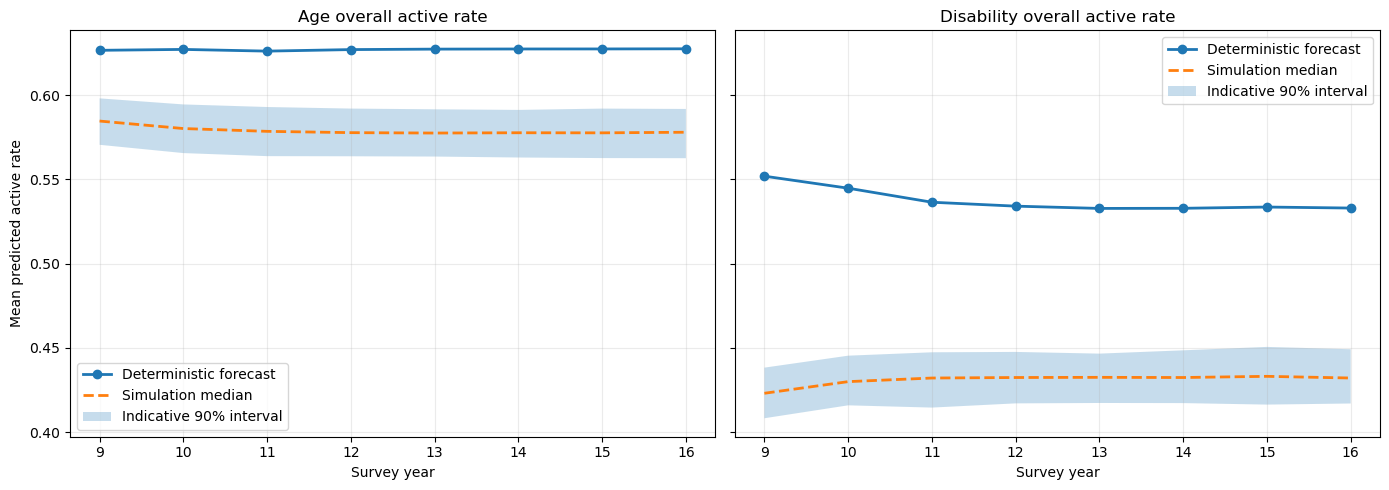

Overall residual simulations completed and saved to: C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\overall_residual_simulation


,year,deterministic_mean_active_rate,simulated_median_mean_active_rate,simulated_lower_90_mean_active_rate,simulated_upper_90_mean_active_rate,task
0,9,0.6266,0.5846,0.5705,0.5981,age_overall_level
1,10,0.6271,0.5802,0.5656,0.5945,age_overall_level
2,11,0.6261,0.5785,0.5638,0.5929,age_overall_level
3,12,0.6270,0.5777,0.5637,0.5920,age_overall_level
4,13,0.6273,0.5775,0.5635,0.5916,age_overall_level
5,14,0.6274,0.5777,0.5630,0.5912,age_overall_level
6,15,0.6274,0.5776,0.5626,0.5920,age_overall_level
7,16,0.6275,0.5780,0.5626,0.5918,age_overall_level
8,9,0.5519,0.4230,0.4082,0.4382,disability_overall_level
9,10,0.5448,0.4299,0.4159,0.4453,disability_overall_level


In [13]:
combined_mean_summary = pd.concat([age_simulation_result[1].assign(task='age_overall_level'), disability_simulation_result[1].assign(task='disability_overall_level')], ignore_index=True)
combined_residual_diagnostics = pd.concat([age_simulation_result[2], disability_simulation_result[2]], ignore_index=True)
combined_specification = pd.concat([age_simulation_result[3], disability_simulation_result[3]], ignore_index=True)
combined_mean_summary.to_csv(SIMULATION_DIR / 'overall_mean_active_rate_indicative_intervals.csv', index=False)
combined_residual_diagnostics.to_csv(SIMULATION_DIR / 'overall_alr_residual_diagnostics.csv', index=False)
combined_specification.to_csv(SIMULATION_DIR / 'overall_residual_simulation_specification.csv', index=False)
figure, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, task_name, title in zip(axes, ['age_overall_level', 'disability_overall_level'], ['Age overall active rate', 'Disability overall active rate']):
    plot_frame = combined_mean_summary[combined_mean_summary['task'] == task_name].sort_values('year')
    axis.plot(plot_frame['year'], plot_frame['deterministic_mean_active_rate'], marker='o', linewidth=2, label='Deterministic forecast')
    axis.plot(plot_frame['year'], plot_frame['simulated_median_mean_active_rate'], linestyle='--', linewidth=2, label='Simulation median')
    axis.fill_between(plot_frame['year'], plot_frame['simulated_lower_90_mean_active_rate'], plot_frame['simulated_upper_90_mean_active_rate'], alpha=0.25, label='Indicative 90% interval')
    axis.set_title(title)
    axis.set_xlabel('Survey year')
    axis.grid(alpha=0.25)
axes[0].set_ylabel('Mean predicted active rate')
axes[0].legend()
axes[1].legend()
figure.tight_layout()
figure.savefig(SIMULATION_DIR / 'overall_mean_active_rate_indicative_intervals.png', dpi=300, bbox_inches='tight')
plt.show()
assert set(combined_mean_summary['task']) == set(OVERALL_TASKS)
assert combined_mean_summary.groupby('task')['year'].nunique().eq(FORECAST_HORIZON).all()
print('Overall residual simulations completed and saved to:', SIMULATION_DIR)
display(combined_mean_summary.round(4))


# Part C. ALR epsilon sensitivity

In [14]:
def shares_to_alr_eps(shares, epsilon):
    clipped = np.clip(np.asarray(shares, dtype=float), epsilon, 1)
    clipped = clipped / clipped.sum(axis=1, keepdims=True)
    return np.log(clipped[:, :2] / clipped[:, [2]])

ALR_EPSILON_CANDIDATES = [1e-4, 1e-5, 1e-6]
COMPOSITION_TASKS = [name for name, cfg in TASKS.items() if cfg['is_composition']]

def fit_and_evaluate_epsilon(prepared, config, model_name, parameters, epsilon, lag1_cols, numeric, interaction_cols):
    targets = config['target_cols']
    history_feature_cols = [c for c in numeric if c not in ['time_trend', 'is_covid_year']]
    required_train = targets + [config['weight_col']]
    train = prepared[prepared['year'] <= TRAIN_END_YEAR].dropna(subset=required_train).copy()
    test = prepared[prepared['year'] == TEST_YEAR].dropna(subset=targets + history_feature_cols + [config['n_col']]).copy()
    weights = pd.to_numeric(train[config['weight_col']], errors='coerce').to_numpy(dtype=float)
    actual = test[targets].to_numpy(dtype=float)

    numeric_for_model = numeric + interaction_cols if model_name == 'Ridge Regression' else numeric
    model = build_model(model_name, parameters, numeric_for_model, config['panel_keys'], True)
    response = shares_to_alr_eps(train[targets], epsilon)
    model.fit(train[numeric_for_model + config['panel_keys']], response, model__sample_weight=weights)
    raw_prediction = model.predict(test[numeric_for_model + config['panel_keys']])
    predicted = alr_to_shares(raw_prediction)

    metrics = score_predictions(actual, predicted, test[config['n_col']].to_numpy(dtype=float), config)
    metrics.update({'task': config['task'], 'fixed_model': model_name, 'alr_epsilon': epsilon})
    return metrics

epsilon_rows = []
for task_name in COMPOSITION_TASKS:
    config = TASKS[task_name]
    frame = TASK_FRAMES[task_name]
    prepared, lag1_cols, numeric, interaction_cols = prepare_task(frame, config)
    model_name = select_best_model(summary, task_name, config['selection_metric'])
    if model_name == 'Naive baseline':
        print(task_name, 'skipped: Naive baseline does not use ALR transform')
        continue
    parameters = get_best_params(task_name, model_name)
    for epsilon in ALR_EPSILON_CANDIDATES:
        print(task_name, epsilon, model_name)
        metrics = fit_and_evaluate_epsilon(prepared, config, model_name, parameters, epsilon, lag1_cols, numeric, interaction_cols)
        epsilon_rows.append(metrics)

alr_epsilon_results = pd.DataFrame(epsilon_rows)
alr_epsilon_results.to_csv(SENSITIVITY_DIR / 'alr_epsilon_sensitivity_metrics.csv', index=False)

alr_epsilon_pivot = alr_epsilon_results.pivot(index='task', columns='alr_epsilon', values='total_variation')
alr_epsilon_pivot.to_csv(SENSITIVITY_DIR / 'alr_epsilon_sensitivity_pivot.csv')
display(alr_epsilon_pivot.round(6))

age_overall_level 0.0001 Gradient Boosting
age_overall_level 1e-05 Gradient Boosting
age_overall_level 1e-06 Gradient Boosting
disability_overall_level 0.0001 Gradient Boosting
disability_overall_level 1e-05 Gradient Boosting
disability_overall_level 1e-06 Gradient Boosting
age_activity_level 0.0001 Random Forest
age_activity_level 1e-05 Random Forest
age_activity_level 1e-06 Random Forest
disability_activity_level 0.0001 Gradient Boosting
disability_activity_level 1e-05 Gradient Boosting
disability_activity_level 1e-06 Gradient Boosting


alr_epsilon,0.000001,0.000010,0.000100
task,,,
age_activity_level,0.008036,0.007887,0.007874
age_overall_level,0.108290,0.108290,0.108290
disability_activity_level,0.008058,0.007940,0.008020
disability_overall_level,0.184113,0.184140,0.184142


# Part D. COVID indicator with/without sensitivity

In [15]:
def fit_and_evaluate_covid_variant(prepared, config, model_name, parameters, include_covid, lag1_cols, numeric, interaction_cols):
    targets = config['target_cols']
    numeric_variant = numeric if include_covid else [c for c in numeric if c != 'is_covid_year']
    history_feature_cols = [c for c in numeric_variant if c not in ['time_trend', 'is_covid_year']]
    required_train = targets + [config['weight_col']]
    train = prepared[prepared['year'] <= TRAIN_END_YEAR].dropna(subset=required_train).copy()
    test = prepared[prepared['year'] == TEST_YEAR].dropna(subset=targets + history_feature_cols + [config['n_col']]).copy()
    weights = pd.to_numeric(train[config['weight_col']], errors='coerce').to_numpy(dtype=float)
    actual = test[targets].to_numpy(dtype=float)

    if model_name == 'Naive baseline':
        predicted = test[lag1_cols].to_numpy(dtype=float)
    else:
        numeric_for_model = numeric_variant + interaction_cols if model_name == 'Ridge Regression' else numeric_variant
        model = build_model(model_name, parameters, numeric_for_model, config['panel_keys'], config['is_composition'])
        response = shares_to_alr(train[targets]) if config['is_composition'] else train[targets[0]].to_numpy(dtype=float)
        model.fit(train[numeric_for_model + config['panel_keys']], response, model__sample_weight=weights)
        raw_prediction = model.predict(test[numeric_for_model + config['panel_keys']])
        predicted = alr_to_shares(raw_prediction) if config['is_composition'] else np.clip(raw_prediction, 0, 1).reshape(-1, 1)

    metrics = score_predictions(actual, predicted, test[config['n_col']].to_numpy(dtype=float), config)
    metrics.update({'task': config['task'], 'fixed_model': model_name, 'covid_indicator': 'with' if include_covid else 'without'})
    return metrics

covid_rows = []
for task_name, config in TASKS.items():
    frame = TASK_FRAMES[task_name]
    prepared, lag1_cols, numeric, interaction_cols = prepare_task(frame, config)
    model_name = select_best_model(summary, task_name, config['selection_metric'])
    parameters = get_best_params(task_name, model_name) if model_name != 'Naive baseline' else {}
    for include_covid in [True, False]:
        print(task_name, 'with' if include_covid else 'without', model_name)
        metrics = fit_and_evaluate_covid_variant(prepared, config, model_name, parameters, include_covid, lag1_cols, numeric, interaction_cols)
        covid_rows.append(metrics)

covid_sensitivity_results = pd.DataFrame(covid_rows)
covid_sensitivity_results.to_csv(SENSITIVITY_DIR / 'covid_indicator_sensitivity_metrics.csv', index=False)

covid_pivot = covid_sensitivity_results.pivot(
    index='task', columns='covid_indicator',
    values='total_variation'
).combine_first(
    covid_sensitivity_results.pivot(index='task', columns='covid_indicator', values=[c for c in covid_sensitivity_results.columns if c.endswith('_mae')][0]) if any(c.endswith('_mae') for c in covid_sensitivity_results.columns) else pd.DataFrame()
)
display(covid_sensitivity_results.round(6))

age_overall_level with Gradient Boosting
age_overall_level without Gradient Boosting
disability_overall_level with Gradient Boosting
disability_overall_level without Gradient Boosting
age_activity_level with Random Forest
age_activity_level without Random Forest
disability_activity_level with Gradient Boosting
disability_activity_level without Gradient Boosting
age_months12 with Naive baseline
age_months12 without Naive baseline
disability_months12 with Ridge Regression
disability_months12 without Ridge Regression
age_days10p60gr with Naive baseline
age_days10p60gr without Naive baseline
disability_days10p60gr with Gradient Boosting
disability_days10p60gr without Gradient Boosting


,observations,total_variation,overall_mae,overall_rmse,overall_inactive_rate_mae,overall_inactive_rate_rmse,overall_inactive_rate_r2,overall_fairly_active_rate_mae,overall_fairly_active_rate_rmse,overall_fairly_active_rate_r2,...,months12_rate_r2,participation_MONTHS_12_mae,participation_MONTHS_12_rmse,participation_MONTHS_12_r2,days10p60gr_rate_mae,days10p60gr_rate_rmse,days10p60gr_rate_r2,participation_DAYS10P60GR_mae,participation_DAYS10P60GR_rmse,participation_DAYS10P60GR_r2
0,256,0.108290,0.072194,0.109400,0.085302,0.126086,0.428950,0.042424,0.058937,-0.008424,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,256,0.107703,0.071802,0.109061,0.084464,0.125662,0.432781,0.042432,0.059020,-0.011270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,504,0.184113,0.122742,0.176030,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,504,0.184269,0.122846,0.175860,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31585,0.008036,0.005358,0.024111,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,31585,0.008157,0.005438,0.024458,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,62392,0.008058,0.005372,0.034877,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,62392,0.008062,0.005375,0.034890,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,31585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.819348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,31585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.819348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Part E. Cross-model robustness for headline conclusions

In [20]:
def refit_and_recurse(frame, config, model_name, parameters, horizon=8, start_year=9):
    prepared = add_lag_features(frame, config['panel_keys'], config['target_cols'], config['feature_level'])
    train_all = prepared.dropna(subset=config['target_cols'] + [config['weight_col']]).copy()

    numeric_for_model = [f'{c}_lag1' for c in config['target_cols']]
    extra = [f'{c}_lag2' if config['feature_level'] == 'overall' else f'{c}_roll2' for c in config['target_cols']]
    numeric_for_model = numeric_for_model + extra + ['time_trend', 'is_covid_year']
    interaction_cols = []

    if model_name != 'Naive baseline':
        if model_name == 'Ridge Regression':
            train_all, interaction_cols = add_interaction_terms(train_all, config['panel_keys'][1])
            numeric_for_model = numeric_for_model + interaction_cols

        weights = pd.to_numeric(train_all[config['weight_col']], errors='coerce').to_numpy(dtype=float)
        model = build_model(model_name, parameters, numeric_for_model, config['panel_keys'], config['is_composition'])
        response = shares_to_alr(train_all[config['target_cols']])
        model.fit(train_all[numeric_for_model + config['panel_keys']], response, model__sample_weight=weights)
    else:
        model = None

    seed = prepared[prepared['year'].isin([7, 8])].copy()
    history = {}
    for key, grp in seed.sort_values('year').groupby(config['panel_keys']):
        history[key] = grp[config['target_cols']].to_numpy().tolist()

    keys = list(history.keys())
    records = []

    for step in range(1, horizon + 1):
        forecast_year = start_year + step - 1
        rows = []

        for key in keys:
            vals = history[key]
            last = vals[-1]
            prev = vals[-2] if len(vals) >= 2 else last
            row = dict(zip(config['panel_keys'], key))

            for i, col in enumerate(config['target_cols']):
                row[f'{col}_lag1'] = last[i]
                if config['feature_level'] == 'overall':
                    row[f'{col}_lag2'] = prev[i]
                else:
                    row[f'{col}_roll2'] = (last[i] + prev[i]) / 2.0

            row['time_trend'] = forecast_year / YEAR_REF
            row['is_covid_year'] = 0
            rows.append(row)

        features = pd.DataFrame(rows)

        if model_name == 'Naive baseline':
            predicted = np.asarray([history[key][-1] for key in keys], dtype=float)
        else:
            model_input = features.copy()
            if model_name == 'Ridge Regression':
                model_input, _ = add_interaction_terms(model_input, config['panel_keys'][1], expected_cols=interaction_cols)
            predicted = alr_to_shares(model.predict(model_input[numeric_for_model + config['panel_keys']]))

        step_result = features[config['panel_keys']].copy()
        step_result['year'] = forecast_year

        for i, col in enumerate(config['target_cols']):
            step_result[col] = predicted[:, i]

        records.append(step_result)

        for idx, key in enumerate(keys):
            history[key] = [history[key][-1], predicted[idx].tolist()]

    return pd.concat(records, ignore_index=True)


MODEL_FAMILIES = ['Ridge Regression', 'Random Forest', 'Gradient Boosting', 'Naive baseline']

cross_model_results = {}

for model_name in MODEL_FAMILIES:
    print('Running:', model_name)

    params_age = {} if model_name == 'Naive baseline' else get_best_params('age_overall_level', model_name)
    forecast_age = refit_and_recurse(age_overall, TASKS['age_overall_level'], model_name, params_age)
    age_85plus = forecast_age[forecast_age['age_group'] == '85+'].groupby('year')['overall_active_rate'].mean().sort_index()

    params_dis = {} if model_name == 'Naive baseline' else get_best_params('disability_overall_level', model_name)
    forecast_dis = refit_and_recurse(disability_overall, TASKS['disability_overall_level'], model_name, params_dis)

    dis_group_mean = (
        forecast_dis[forecast_dis['disability_group'].isin(['no_disability', 'limiting_disability'])]
        .groupby(['year', 'disability_group'], as_index=False)['active_rate']
        .mean()
    )

    dis_pivot = dis_group_mean.pivot(index='year', columns='disability_group', values='active_rate')
    dis_gap = (dis_pivot['no_disability'] - dis_pivot['limiting_disability']).sort_index()

    cross_model_results[model_name] = {
        'age_85plus_year9': age_85plus.loc[9],
        'age_85plus_year16': age_85plus.loc[16],
        'age_85plus_change': age_85plus.loc[16] - age_85plus.loc[9],
        'disability_gap_year9': dis_gap.loc[9],
        'disability_gap_year16': dis_gap.loc[16],
        'disability_gap_change': dis_gap.loc[16] - dis_gap.loc[9],
    }

cross_model_summary = pd.DataFrame(cross_model_results).T

cross_model_summary['age_85plus_direction'] = np.where(
    cross_model_summary['age_85plus_change'] < 0, 'declined', 'not declined'
)

cross_model_summary['disability_gap_direction'] = np.where(
    cross_model_summary['disability_gap_change'] > 0, 'widened', 'not widened'
)

cross_model_summary.to_csv(
    SENSITIVITY_DIR / 'cross_model_robustness_headline_directions.csv'
)

display(cross_model_summary.round(4))


Running: Ridge Regression
Running: Random Forest
Running: Gradient Boosting
Running: Naive baseline


,age_85plus_year9,age_85plus_year16,age_85plus_change,disability_gap_year9,disability_gap_year16,disability_gap_change,age_85plus_direction,disability_gap_direction
Ridge Regression,0.1951,0.2504,0.0553,0.1419,0.0816,-0.0603,not declined,not widened
Random Forest,0.1814,0.0099,-0.1715,0.1794,0.2026,0.0232,declined,widened
Gradient Boosting,0.3478,0.3067,-0.0411,0.1911,0.2064,0.0153,declined,widened
Naive baseline,0.3532,0.3532,0.0000,0.1996,0.1996,0.0000,not declined,not widened
